In [300]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [34]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [35]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [36]:
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'
#get cell number 
cell_num = 'c42'


#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = float(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec


patch_channel = patch_filt_c42

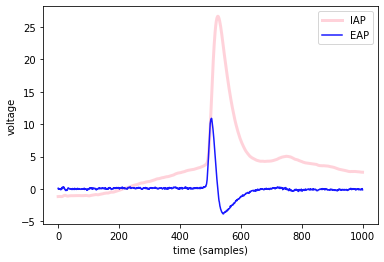

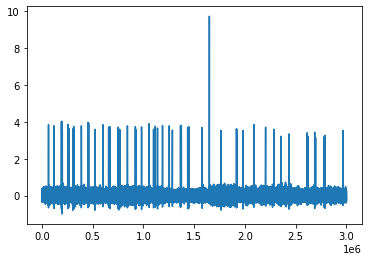

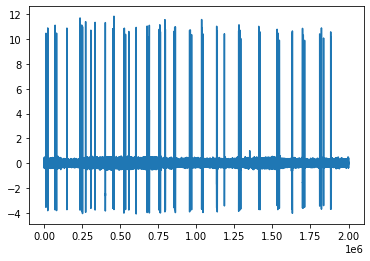

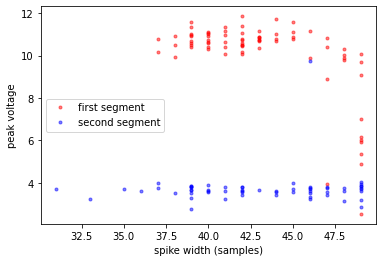

In [65]:


patch_fs = patch_c42

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 10 # this is arbitrary, just to scale it better to the iap

# grab semi-random long segments near the beginning and end
first_segment = iap2eap[:2000000]
last_segment = iap2eap[37521059:40521059]

# show that the pseudo-eap works
plt.plot(patch_filt[23000:24000], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[23000:24000], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()

plt.plot(iap2eap[37521059:40521059])
plt.show()
plt.plot(iap2eap[:2000000])
plt.show()
# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 2, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 2, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

40521059

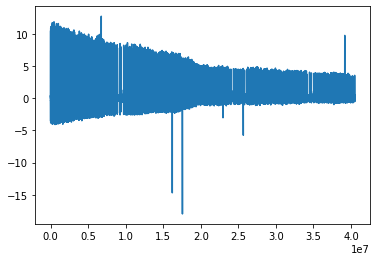

In [61]:
plt.plot(iap2eap)
len(iap2eap)

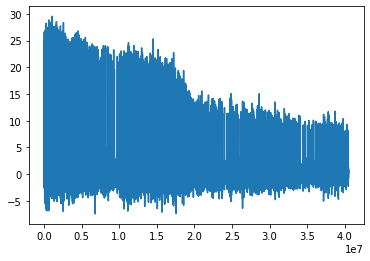

In [52]:
plt.plot(patch_filt)